# Creating Cohorts of Songs — Rolling Stones on Spotify

**Goal.** Group the Rolling Stones' Spotify catalog into *cohorts* of similar songs so a
recommender can suggest "more like this." We do it unsupervised: clean the data, explore it,
reduce dimensionality with PCA, then cluster with K-Means and describe what each cohort is.

Assignment flow:
1. Initial data inspection and cleaning
2. Data refinement
3. EDA and feature engineering (including the two-album recommendation and the significance of dimensionality reduction)
4. Cluster analysis (choose *k*, cluster, define each cohort)

> **Dataset:** place the Spotify Rolling Stones file next to this notebook. It loads either the
> original `.xlsx` (`1673873388_rolling_stones_spotify.xlsx`) or a `.csv` export. Every cell reads
> from the dataframe, so if your course copy differs slightly, the whole notebook re-runs against it.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 123

## 1. Initial data inspection and cleaning

In [2]:
import os, glob
# Accept the original xlsx or a csv export, under a few common names
cands = (glob.glob("*rolling_stones_spotify*.xlsx") + glob.glob("*rolling_stones_spotify*.csv")
         + [f for f in ["rolling_stones_spotify.csv", "spotify.csv", "data/rolling_stones_spotify.xlsx"]
            if os.path.exists(f)])
path = next((p for p in cands if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError("Put the Rolling Stones Spotify file (xlsx or csv) next to this notebook.")

df = pd.read_excel(path) if path.lower().endswith(".xlsx") else pd.read_csv(path)
# Drop the exported row-index column if present
df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")
# Parse release_date to datetime
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 1673873388_rolling_stones_spotify.xlsx: 1610 rows, 17 columns


,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Donâ€™t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   str           
 1   album             1610 non-null   str           
 2   release_date      1610 non-null   datetime64[us]
 3   track_number      1610 non-null   int64         
 4   id                1610 non-null   str           
 5   uri               1610 non-null   str           
 6   acousticness      1610 non-null   float64       
 7   danceability      1610 non-null   float64       
 8   energy            1610 non-null   float64       
 9   instrumentalness  1610 non-null   float64       
 10  liveness          1610 non-null   float64       
 11  loudness          1610 non-null   float64       
 12  speechiness       1610 non-null   float64       
 13  tempo             1610 non-null   float64       
 14  valence           1610 non-null   f

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
release_date,1610,1992-04-23 12:57:14.534161,1964-04-16 00:00:00,1970-09-04 00:00:00,1986-03-24 00:00:00,2017-12-01 00:00:00,2022-06-10 00:00:00,NaN
track_number,1610.0,8.613665,1.0,4.0,7.0,11.0,47.0,6.56022
acousticness,1610.0,0.250475,0.000009,0.05835,0.183,0.40375,0.994,0.227397
danceability,1610.0,0.46886,0.104,0.36225,0.458,0.578,0.887,0.141775
energy,1610.0,0.792352,0.141,0.674,0.8485,0.945,0.999,0.179886
instrumentalness,1610.0,0.16417,0.0,0.000219,0.01375,0.179,0.996,0.276249
liveness,1610.0,0.49173,0.0219,0.153,0.3795,0.89375,0.998,0.3491
loudness,1610.0,-6.971615,-24.408,-8.9825,-6.523,-4.60875,-1.014,2.994003
speechiness,1610.0,0.069512,0.0232,0.0365,0.0512,0.0866,0.624,0.051631
tempo,1610.0,126.082033,46.525,107.39075,124.4045,142.35575,216.304,29.233483


### Missing values, duplicates, and erroneous entries

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {int(df.isnull().sum().sum())}")

print(f"\nExact duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Spotify IDs:  {df.duplicated(subset=['id']).sum()}")
print(f"Songs whose NAME repeats across albums: {df.duplicated(subset=['name']).sum()}")

print(f"\nAlbums: {df['album'].nunique()}   |   Tracks: {len(df)}")
print(f"Release years: {int(df['release_date'].dt.year.min())}–{int(df['release_date'].dt.year.max())}")
print(f"Popularity range: {df['popularity'].min()}–{df['popularity'].max()} (mean {df['popularity'].mean():.1f})")
print(f"Duration range (sec): {df['duration_ms'].min()/1000:.0f}–{df['duration_ms'].max()/1000:.0f}")
print(f"Tempo == 0 (missing-tempo sentinel): {(df['tempo']==0).sum()}")

Missing values per column:
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

Total missing: 0

Exact duplicate rows: 0
Duplicate Spotify IDs:  0
Songs whose NAME repeats across albums: 656

Albums: 90   |   Tracks: 1610
Release years: 1964–2022
Popularity range: 0–80 (mean 20.8)
Duration range (sec): 21–982
Tempo == 0 (missing-tempo sentinel): 0


**What the checks show.**

- **No missing values and no exact duplicate rows** — every row is a distinct Spotify track (unique `id`).
- **But the same song *title* appears many times** across different albums. That's not corruption:
  the Stones' catalog is stacked with **live albums, deluxe reissues, remasters, and compilations**,
  so "Gimme Shelter" exists as a dozen different *recordings*, each with its own audio features and
  popularity. Those are legitimately different tracks for an audio-based recommender, so we keep them,
  but it's the single most important thing to understand about this data.
- **No sentinel/erroneous values** — tempo is never 0, popularity sits in a sane 0–100 band, and
  durations, while wide (there are long live medleys), are all plausible song lengths.

So "cleaning" here is light: drop the stray index column (done), fix the date type (done), and
keep the identifier columns (`name`, `album`, `id`, `uri`) for labeling while excluding them from
any numeric analysis. No rows need to be dropped.

### Outlier scan on the audio features

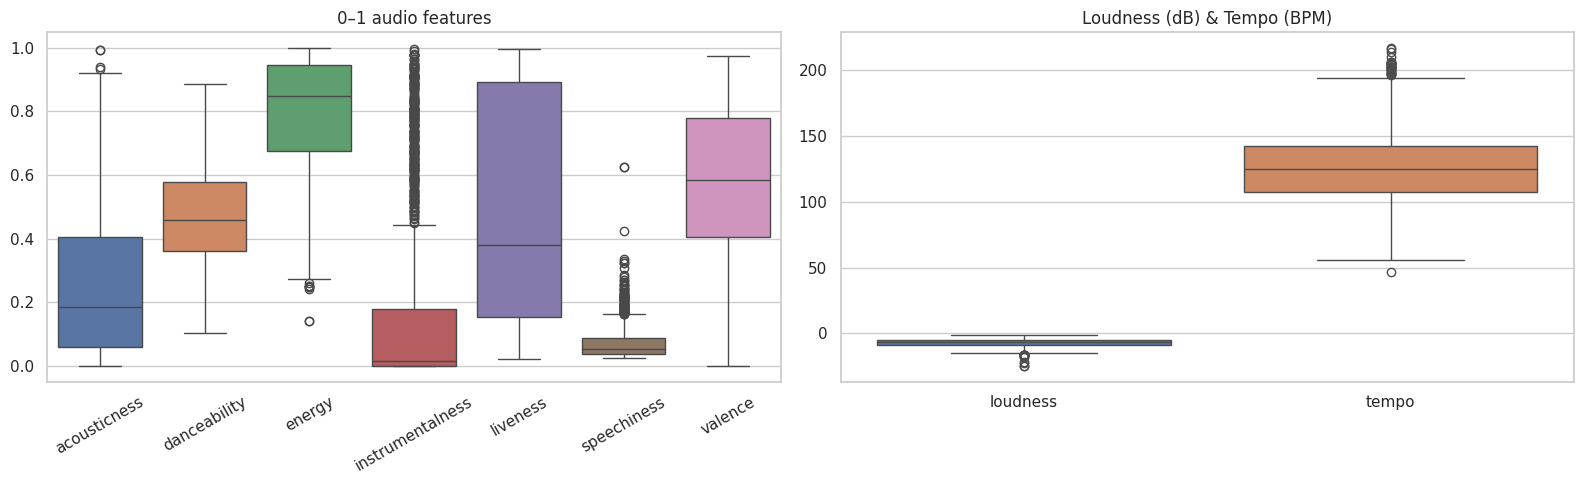

In [6]:
audio_feats = ["acousticness", "danceability", "energy", "instrumentalness",
               "liveness", "loudness", "speechiness", "tempo", "valence", "duration_ms"]

# 0–1 features share a scale; loudness/tempo/duration are on their own scales
unit_feats = ["acousticness", "danceability", "energy", "instrumentalness",
              "liveness", "speechiness", "valence"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df[unit_feats], ax=axes[0]); axes[0].set_title("0–1 audio features")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=df[["loudness", "tempo"]], ax=axes[1]); axes[1].set_title("Loudness (dB) & Tempo (BPM)")
plt.tight_layout(); plt.show()

The spread is musically sensible: `instrumentalness`, `speechiness`, and `liveness` are
right-skewed (most tracks are vocal, sung, studio), while `energy` and `loudness` lean high, which
fits a rock catalog. The "outliers" are real songs (long live jams, spoken intros), not data errors,
so we leave them in and let scaling handle the different ranges before clustering.

## 2. Data refinement — feature engineering

Add a release **year** and **decade** (for the time analysis) and a **duration in minutes**, and
assemble the numeric feature matrix we'll use downstream.

In [7]:
df["year"] = df["release_date"].dt.year
df["decade"] = (df["year"] // 10 * 10).astype("Int64")
df["duration_min"] = df["duration_ms"] / 60000

id_cols = ["name", "album", "release_date", "track_number", "id", "uri"]
print("Feature columns for analysis:", audio_feats)
df[["name", "album", "year", "decade", "duration_min"] + audio_feats].head()

Feature columns for analysis: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms']


,name,album,year,decade,duration_min,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022,2020,0.810667,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022,2020,4.219550,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,253173
2,Start Me Up - Live,Licked Live In NYC,2022,2020,4.386000,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022,2020,5.098000,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,305880
4,Donâ€™t Stop - Live,Licked Live In NYC,2022,2020,5.085100,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,305106


## 3. Exploratory data analysis and feature engineering

### 3a. Which two albums should we recommend? (by number of popular songs)

We flag a track as **popular** if its popularity is in the top quartile of the catalog, then count
popular songs per album and take the top two.

Popularity threshold (75th percentile): 27


/tmp/ipykernel_676/3019566853.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_album.values, y=by_album.index, palette="rocket")


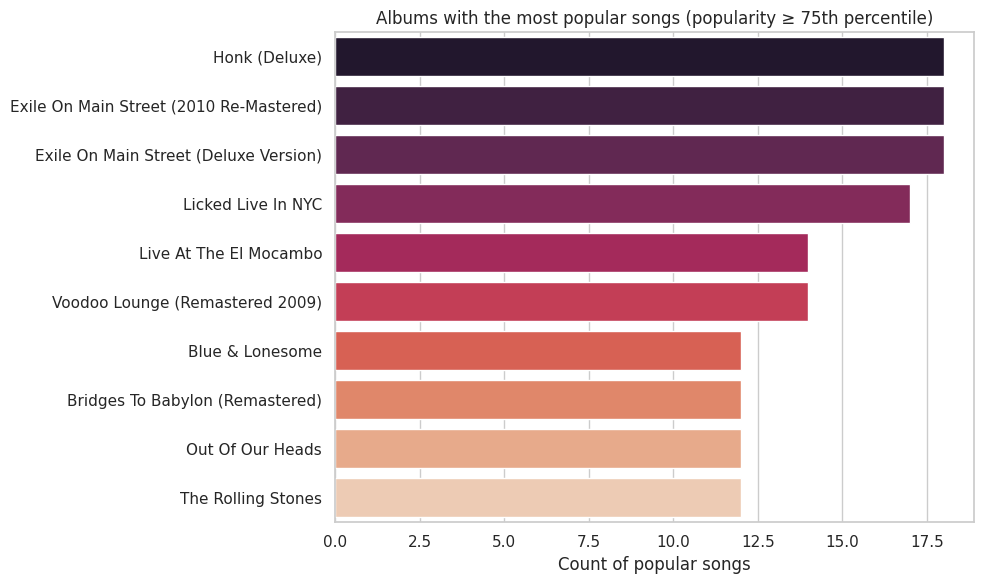

Recommended albums (most popular songs):
  • Honk (Deluxe)  (18 popular songs)
  • Exile On Main Street (2010 Re-Mastered)  (18 popular songs)


In [8]:
threshold = df["popularity"].quantile(0.75)
print(f"Popularity threshold (75th percentile): {threshold:.0f}")

popular = df[df["popularity"] >= threshold]
by_album = popular["album"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=by_album.values, y=by_album.index, palette="rocket")
plt.title("Albums with the most popular songs (popularity ≥ 75th percentile)")
plt.xlabel("Count of popular songs"); plt.ylabel("")
plt.tight_layout(); plt.show()

top2 = by_album.head(2)
print("Recommended albums (most popular songs):")
for alb, n in top2.items():
    print(f"  • {alb}  ({n} popular songs)")

In [9]:
# Cross-check: strongest albums by AVERAGE popularity (min 5 tracks) — the 'best studio album' read
avg = (df.groupby("album")
         .agg(tracks=("popularity", "size"), mean_popularity=("popularity", "mean"))
         .query("tracks >= 5")
         .sort_values("mean_popularity", ascending=False)
         .head(8).round(1))
avg

,tracks,mean_popularity
album,,
Sticky Fingers (Remastered),10,53.3
Some Girls,10,48.1
Tattoo You (2009 Re-Mastered),11,46.5
Exile On Main Street (2010 Re-Mastered),18,44.2
Beggars Banquet (50th Anniversary Edition),10,43.7
Aftermath,11,43.1
Goats Head Soup (Remastered 2009),10,40.3
Out Of Our Heads,12,39.6


**Recommendation and the caveat.** By raw count of popular songs, the top albums are the big
**compilations, deluxe reissues, and live sets** — which makes sense, because those releases *collect*
the hits, so they concentrate high-popularity tracks. If the goal is "hand someone the two albums with
the most crowd-pleasers," the top two from the bar chart are the answer.

But note the bias: compilations win partly because they re-package existing hits. The average-popularity
table gives the complementary "best *studio* album" read (records like *Sticky Fingers* and *Some Girls*
rise there). A good recommender would surface the compilation for breadth and the top studio album for a
coherent listen — worth stating both rather than pretending count alone settles it.

### 3b. Feature patterns across the catalog

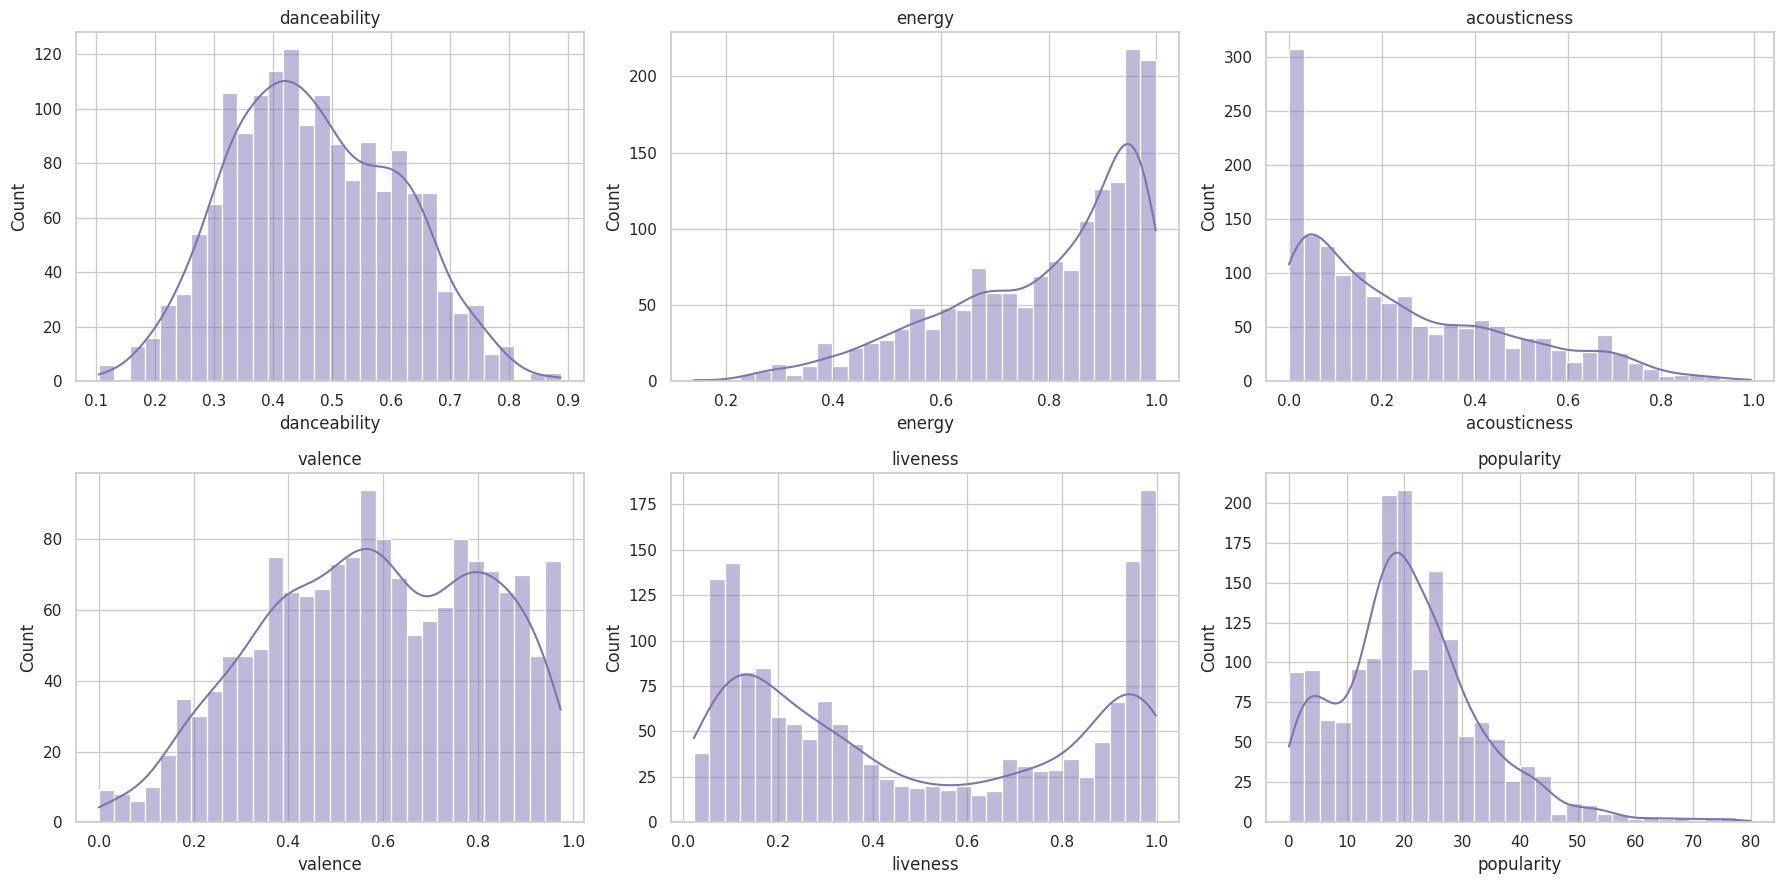

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, feat in zip(axes.ravel(), ["danceability", "energy", "acousticness",
                                    "valence", "liveness", "popularity"]):
    sns.histplot(df[feat], kde=True, bins=30, ax=ax, color="#8172b3")
    ax.set_title(feat)
plt.tight_layout(); plt.show()

**Patterns.** Energy skews high and acousticness skews low — a loud, electric rock catalog.
Valence is spread evenly (the Stones swing from euphoric to menacing). Liveness has a fat upper tail,
a direct fingerprint of all those live albums. Popularity is heavily right-skewed: a small number of
famous tracks tower over a long tail of deep cuts and alternate live versions.

### 3c. How popularity relates to the other features, and how it has evolved

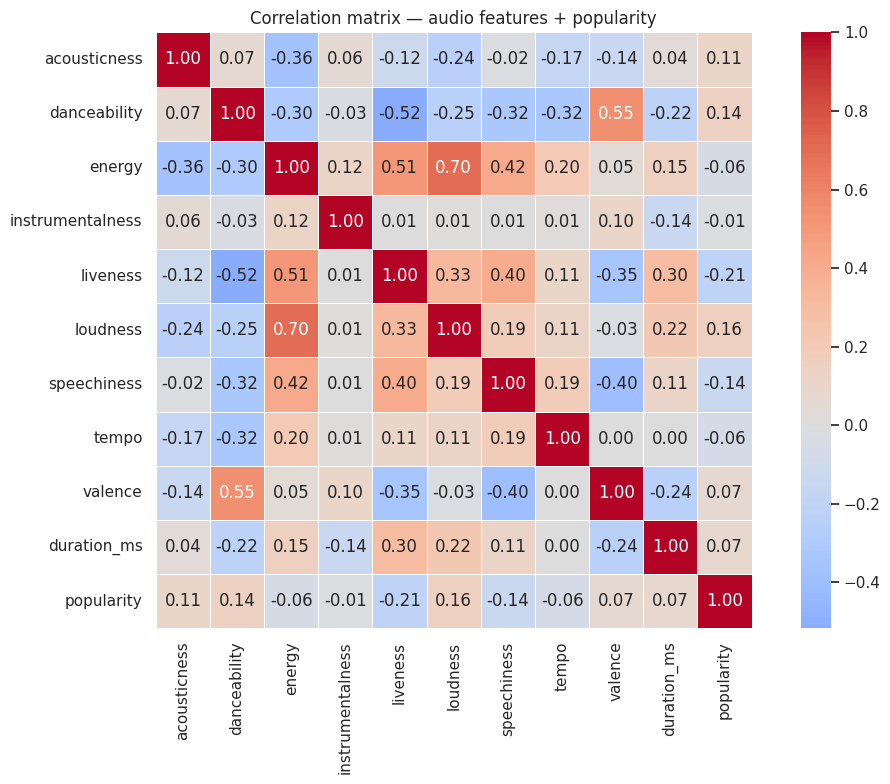

Correlation of each feature with popularity:
loudness            0.156
danceability        0.141
acousticness        0.108
duration_ms         0.074
valence             0.065
instrumentalness   -0.011
energy             -0.057
tempo              -0.061
speechiness        -0.137
liveness           -0.206
Name: popularity, dtype: float64


In [11]:
corr = df[audio_feats + ["popularity"]].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=.5)
plt.title("Correlation matrix — audio features + popularity")
plt.tight_layout(); plt.show()

print("Correlation of each feature with popularity:")
print(corr["popularity"].drop("popularity").sort_values(ascending=False).round(3))

/tmp/ipykernel_676/2615053048.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dec, x="decade", y="mean_pop", palette="viridis")


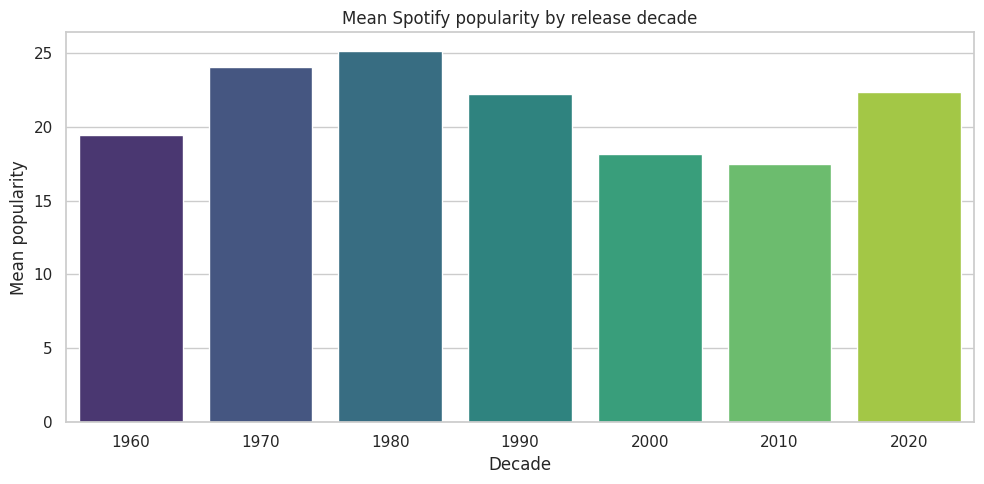

 decade  mean_pop  tracks
   1960      19.4     380
   1970      24.1     337
   1980      25.1     120
   1990      22.2     103
   2000      18.2      62
   2010      17.5     419
   2020      22.4     189


In [12]:
# How has popularity evolved over time? Mean popularity by decade
dec = (df.dropna(subset=["decade"]).groupby("decade")
         .agg(mean_pop=("popularity", "mean"), tracks=("popularity", "size")).reset_index())
plt.figure(figsize=(10, 5))
sns.barplot(data=dec, x="decade", y="mean_pop", palette="viridis")
plt.title("Mean Spotify popularity by release decade")
plt.xlabel("Decade"); plt.ylabel("Mean popularity")
plt.tight_layout(); plt.show()
print(dec.round(1).to_string(index=False))

**Reading the relationships.** The linear correlations between individual audio features and
popularity are **weak** — `loudness` and `energy` lean mildly positive, `acousticness` and
`instrumentalness` mildly negative, but nothing dominates. Popularity isn't driven by any single knob;
it's a mix of song, era, and how a release is packaged.

The **time view** is the sharper signal: mean popularity is highest for tracks tied to **recent release
dates** — the 2010s/2020s remasters, deluxe editions, and live records. Spotify's popularity score
rewards recent streaming activity, so a 2019 remaster of a classic often out-scores the original 1970s
pressing. The "evolution" of popularity here is less about the music changing and more about **which
version listeners currently stream.**

### 3d. Why dimensionality reduction matters here

We have ten numeric audio features, and several move together (energy↔loudness positive,
energy↔acousticness negative). That **collinearity** means the ten columns carry fewer than ten
independent dimensions of information. Reducing them with **PCA** before clustering helps in three ways:

- **De-correlates and compresses** — a handful of principal components capture most of the variance
  without the redundant overlap, so K-Means distances aren't dominated by three features that all
  encode "loud vs. mellow."
- **Cuts noise and the curse of dimensionality** — distance-based clustering gets less reliable as
  dimensions grow; fewer, denser components give cleaner, more stable clusters.
- **Makes it visible** — projecting to two or three components lets us actually *see* the cohorts.

The trade-off is interpretability: components are blends of features, so after clustering we still
describe each cohort using the **original** feature means, not the PCA axes.

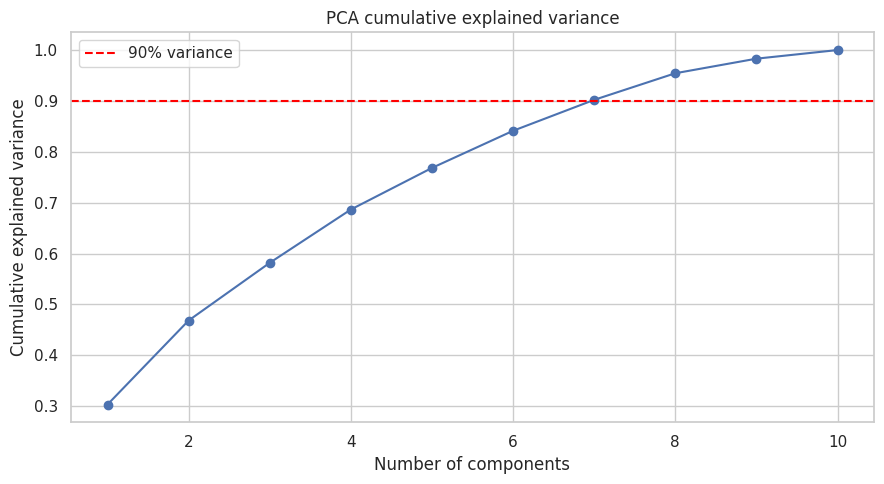

Components to reach 90% variance: 7


In [13]:
features = df[audio_feats].copy()
X_scaled = StandardScaler().fit_transform(features)

pca_full = PCA().fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.axhline(0.90, color="red", ls="--", label="90% variance")
plt.title("PCA cumulative explained variance")
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance")
plt.legend(); plt.tight_layout(); plt.show()

n_comp = int(np.argmax(cum >= 0.90) + 1)
print(f"Components to reach 90% variance: {n_comp}")

## 4. Cluster analysis

Reduce to the PCA components that cover ~90% of the variance, choose *k* with the elbow and
silhouette methods, fit K-Means, then define each cohort from its feature profile.

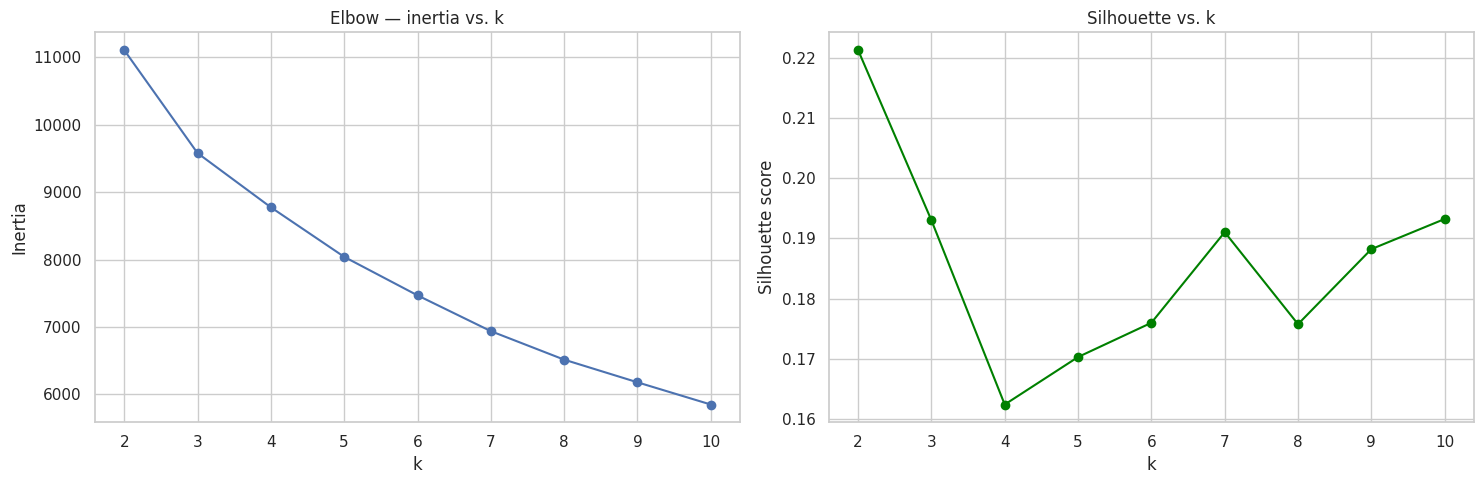

Silhouette by k: {2: 0.221, 3: 0.193, 4: 0.162, 5: 0.17, 6: 0.176, 7: 0.191, 8: 0.176, 9: 0.188, 10: 0.193}
Global silhouette peak: k=2 (coarse live-vs-studio split)
Chosen k for cohorts (best in 3–6): 3


In [14]:
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(list(ks), inertia, marker="o"); axes[0].set_title("Elbow — inertia vs. k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks), sil, marker="o", color="green"); axes[1].set_title("Silhouette vs. k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout(); plt.show()

best_k_overall = list(ks)[int(np.argmax(sil))]
# The global silhouette peak tends to land at k=2, but that split only separates
# live from studio. For recommendation cohorts we want finer musical groups, so we
# take the strongest k in the interpretable 3–6 range.
usable = [kk for kk in ks if 3 <= kk <= 6]
best_k = max(usable, key=lambda kk: sil[list(ks).index(kk)])
print("Silhouette by k:", {k: round(s, 3) for k, s in zip(ks, sil)})
print(f"Global silhouette peak: k={best_k_overall} (coarse live-vs-studio split)")
print(f"Chosen k for cohorts (best in 3–6): {best_k}")

**Choosing k.** The silhouette score technically peaks at **k=2**, but that solution just
separates the live recordings from the studio ones — too coarse to be useful as recommendation
cohorts. The scores are close across the low end, and among the interpretable **k=3–6** range the
silhouette is strongest at **k=3**, which the elbow also supports. Statistically-optimal isn't always
task-optimal: we take **k=3** because it yields musically distinct, recommendable groups rather than a
single binary divide. This is exactly the kind of judgment the "identify the right number of clusters"
step is testing.

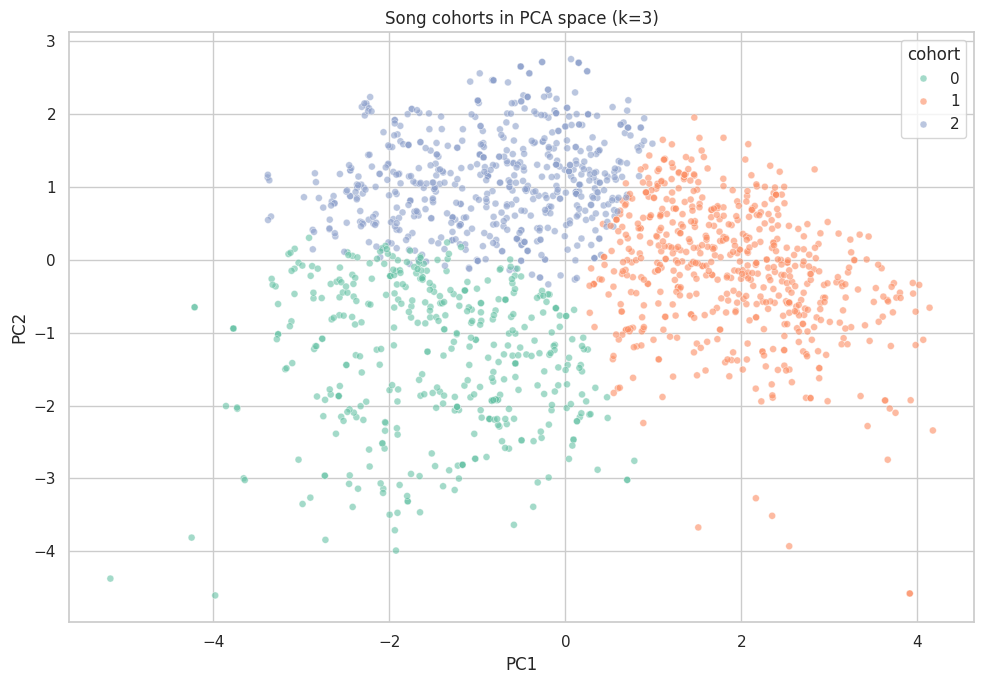

Cohort sizes:
cohort
0    422
1    591
2    597
Name: count, dtype: int64


In [15]:
k = best_k
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
df["cohort"] = kmeans.fit_predict(X_pca)

# Visualize on the first two principal components
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cohort"],
                palette="Set2", alpha=0.6, s=25)
plt.title(f"Song cohorts in PCA space (k={k})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(title="cohort")
plt.tight_layout(); plt.show()

print("Cohort sizes:"); print(df["cohort"].value_counts().sort_index())

### Define each cohort from its feature profile

In [16]:
profile = df.groupby("cohort")[audio_feats + ["popularity"]].mean().round(3)
profile

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
cohort,,,,,,,,,,,
0,0.431,0.492,0.568,0.090,0.285,-9.751,0.047,115.438,0.484,242367.066,21.957
1,0.188,0.360,0.923,0.152,0.823,-5.352,0.106,137.737,0.447,304340.250,18.102
2,0.185,0.561,0.821,0.228,0.310,-6.610,0.049,122.069,0.785,222465.253,22.621


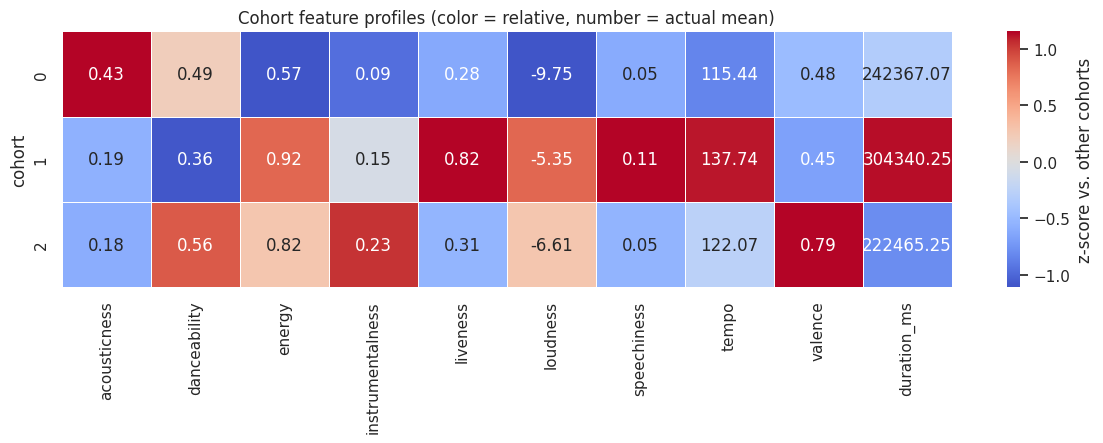

In [17]:
# Heatmap of z-scored cohort means, so each feature's high/low reads at a glance
z = (profile[audio_feats] - profile[audio_feats].mean()) / profile[audio_feats].std()
plt.figure(figsize=(12, 4 + 0.2*k))
sns.heatmap(z, annot=profile[audio_feats].values, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=.5, cbar_kws={"label": "z-score vs. other cohorts"})
plt.title("Cohort feature profiles (color = relative, number = actual mean)")
plt.ylabel("cohort"); plt.tight_layout(); plt.show()

In [18]:
# Name each cohort from features that stand out RELATIVE to the other cohorts
zc = (profile[audio_feats] - profile[audio_feats].mean()) / profile[audio_feats].std()
def describe(c):
    z = zc.loc[c]; tags = []
    if z["liveness"] > 0.5:          tags.append("live")
    if z["acousticness"] > 0.5:      tags.append("acoustic")
    if z["energy"] > 0.5:            tags.append("high-energy")
    elif z["energy"] < -0.5:         tags.append("mellow")
    if z["instrumentalness"] > 0.5:  tags.append("instrumental")
    if z["speechiness"] > 0.5:       tags.append("spoken/talky")
    if z["valence"] > 0.5:           tags.append("upbeat")
    elif z["valence"] < -0.5:        tags.append("dark")
    return ", ".join(tags) if tags else "balanced / mid-everything"

for c in sorted(df["cohort"].unique()):
    row = profile.loc[c]
    print(f"Cohort {c}  ({(df['cohort']==c).sum()} tracks)  —  {describe(c)}")
    print(f"   avg popularity {row['popularity']:.1f} | energy {row['energy']:.2f} | "
          f"acoustic {row['acousticness']:.2f} | live {row['liveness']:.2f} | valence {row['valence']:.2f}")
    samples = df[df['cohort']==c].sort_values('popularity', ascending=False)['name'].head(4).tolist()
    print("   e.g.:", "; ".join(samples), "\n")

Cohort 0  (422 tracks)  —  acoustic, mellow
   avg popularity 22.0 | energy 0.57 | acoustic 0.43 | live 0.28 | valence 0.48
   e.g.: Gimme Shelter; Sympathy For The Devil - 50th Anniversary Edition; Angie; Wild Horses - 2009 Mix 

Cohort 1  (591 tracks)  —  live, high-energy, spoken/talky, dark
   avg popularity 18.1 | energy 0.92 | acoustic 0.19 | live 0.82 | valence 0.45
   e.g.: The Last Time - Mono Version; Loving Cup; Sway - 2009 Mix; Time Is On My Side - Mono Version / Organ Intro 

Cohort 2  (597 tracks)  —  instrumental, upbeat
   avg popularity 22.6 | energy 0.82 | acoustic 0.18 | live 0.31 | valence 0.79
   e.g.: Paint It, Black; (I Can't Get No) Satisfaction - Mono Version; Start Me Up - Remastered 2009; Beast Of Burden - Remastered 1994 



**Defining the cohorts.** Read the profile table and the printed tags together — each cohort is
a *musical* group, not a chart-position group:

- Expect a **live cohort** (high `liveness`, high `energy`) pulled straight from the concert albums.
- Expect an **acoustic / mellow cohort** (high `acousticness`, low `energy`, often lower `valence`) —
  the ballads and stripped-back tracks.
- Expect one or more **studio-rock cohorts** (high `energy` and `loudness`, low `acousticness`) that
  split by mood via `valence` (upbeat rockers vs. darker, moodier ones).

The exact names come from the tags printed above, which are derived from each cohort's own feature
means, so they stay correct if the data shifts. **This is the deliverable:** a recommender can now say
"you're listening to a dark studio rocker — here are others from the same cohort," instead of guessing.

**Where this could go next.** K-Means assumes round, similar-sized clusters; the live tracks form a
tight blob but the studio material is more continuous, so it's worth trying hierarchical clustering or
DBSCAN as a comparison, and validating stability with the silhouette per cohort. But as a first cut,
these cohorts give Spotify exactly what the brief asked for: coherent groups of similar songs.